# 13 — CV simultaneous ABCD expected limits with signal leakage

MC-only background Asimov data를 사용하면서 A/B/C/D를 동시에 fit한다. 각 topology에서 B/C/D background rate는 Poisson term으로 profile하고, A background는 $\kappa\,B C/D$로 연결한다. Signal은 A/B/C/D 전 영역에 포함한다.

- $\kappa=(N_A N_D)/(N_B N_C)$는 background MC에서 계산한다.
- $\kappa$의 MC `sumw2` 오차는 A-background 전용 log-normal constraint로 넣는다.
- Background histogram variance는 0으로 두어 control-region Poisson 정보와 MC template-stat의 중복을 피한다.
- Signal의 영역별 `sumw2`는 `autoMCStats`, luminosity 2.5%는 모든 signal region에 correlated nuisance로 넣는다.


In [1]:
from pathlib import Path
import os, re, shlex, subprocess, sys
import coffea.util
import hist
import numpy as np
import pandas as pd
import uproot
import yaml
from IPython.display import display

if int(np.__version__.split('.')[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault('numpy._core', _numpy_core)
    sys.modules.setdefault('numpy._core.numeric', _numpy_numeric)

BASE = Path.cwd().resolve()
if BASE.name != 'ABCD_Study':
    candidates = [BASE/'studies'/'ABCD_Study', BASE/'sidm'/'studies'/'ABCD_Study']
    BASE = next((p for p in candidates if p.is_dir()), candidates[-1])
REPOSITORY_PARENT = BASE.parents[2]
if str(REPOSITORY_PARENT) not in sys.path: sys.path.insert(0, str(REPOSITORY_PARENT))
BKG_DIR = BASE/'ABCD_landing_10ch_cosmic_veto_v1_bkg_full_merged_samples_v1'
SIGNAL_DIR = BASE/'ABCD_landing_10ch_cosmic_veto_v1_signal_full_merged_samples_v1'
SIGNAL_YAMLS = [BASE.parents[1]/'configs/ntuples/signal_2mu2e_v10.yaml',
                BASE.parents[1]/'configs/ntuples/signal_4mu_v10.yaml']
OUT = BASE/'combine_cv_simultaneous_abcd'
SHAPES, CARDS, RESULTS = [OUT/x for x in ('shapes','datacards','results')]
CMSSW = Path(os.environ.get('COMBINE_CMSSW_BASE', '/home/cms-jovyan/CMSSW_16_0_0'))
RUN_COMBINE = False
RUN_SCOPE = 'full'  # Validate one physical point before changing to 'full'.
RMAX_OVERRIDES = {}
for directory in (OUT, SHAPES, CARDS, RESULTS): directory.mkdir(parents=True, exist_ok=True)
print(BASE, BKG_DIR, SIGNAL_DIR, CMSSW, RUN_SCOPE, RUN_COMBINE, sep='\n')


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_landing_10ch_cosmic_veto_v1_bkg_full_merged_samples_v1
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/ABCD_landing_10ch_cosmic_veto_v1_signal_full_merged_samples_v1
/home/cms-jovyan/CMSSW_16_0_0
full
False


## 1. Background MC A/B/C/D and κ constraint


In [2]:
CFG = {
    '2mu2e': {'hist':'mulj_egmlj_iso', 'channel':'test_SR_2mu2e_spread_cosAlpha_mu_veto', 'cuts':(0.25,0.10)},
    '4mu': {'hist':'mulj_mulj_iso', 'channel':'test_SR_4mu_spread_cosAlpha_mu_veto', 'cuts':(0.25,0.25)},
}
REGIONS = 'ABCD'
BKG_PREFIXES = ('QCD_', 'DYJetsTo', 'TTJets', 'WW', 'WZ', 'ZZ')

def load_hist(path, hist_name, channel):
    loaded = coffea.util.load(path)
    payload = loaded.get('out', loaded)[path.stem]
    h2d = payload['hists'][hist_name]
    return h2d[{'channel':channel}] if 'channel' in h2d.axes.name else h2d

def sum_hists(paths, hist_name, channel):
    pieces = [load_hist(path, hist_name, channel) for path in paths]
    if not pieces: raise ValueError(f'No input for {hist_name}/{channel}')
    total = pieces[0].copy()
    for piece in pieces[1:]: total = total + piece
    return total

def values_variances(h2d):
    values = np.asarray(h2d.values(flow=True), float).copy()
    variances = h2d.variances(flow=True)
    variances = np.clip(values,0,None) if variances is None else np.asarray(variances,float).copy()
    values[-2,:] += values[-1,:]; variances[-2,:] += variances[-1,:]
    values = values[:-1,:]; variances = variances[:-1,:]
    values[:,-2] += values[:,-1]; variances[:,-2] += variances[:,-1]
    values = values[:,:-1]; variances = variances[:,:-1]
    return values[1:,1:], variances[1:,1:]

def region_stats(h2d, cuts):
    values, variances = values_variances(h2d)
    x = np.asarray(h2d.axes[0].centers)[:,None]
    y = np.asarray(h2d.axes[1].centers)[None,:]
    masks = {'A':(x<cuts[0])&(y<cuts[1]), 'B':(x>=cuts[0])&(y<cuts[1]),
             'C':(x<cuts[0])&(y>=cuts[1]), 'D':(x>=cuts[0])&(y>=cuts[1])}
    out = {}
    for region, mask in masks.items():
        value = float(values[mask].sum())
        variance = float(np.clip(variances[mask].sum(),0,None))
        out[region] = {'yield':value, 'variance':variance, 'error':np.sqrt(variance)}
    return out

bkg_paths = sorted(p for p in BKG_DIR.glob('*.coffea') if p.stem.startswith(BKG_PREFIXES))
background = {}
bkg_rows = []
for topology, cfg in CFG.items():
    stats = region_stats(sum_hists(bkg_paths,cfg['hist'],cfg['channel']),cfg['cuts'])
    if any(stats[r]['yield'] <= 0 for r in REGIONS): raise ValueError(f'Non-positive background: {topology} {stats}')
    y = {r:stats[r]['yield'] for r in REGIONS}; v = {r:stats[r]['variance'] for r in REGIONS}
    kappa = y['A']*y['D']/(y['B']*y['C'])
    kappa_rel_variance = sum(v[r]/y[r]**2 for r in REGIONS)
    background[topology] = {'regions':stats, 'kappa':kappa, 'kappa_rel_error':np.sqrt(kappa_rel_variance)}
    for region in REGIONS: bkg_rows.append({'topology':topology,'region':region,**stats[region]})
bkg_table = pd.DataFrame(bkg_rows)
kappa_table = pd.DataFrame([{'topology':t,'kappa':p['kappa'],'kappa_rel_error':p['kappa_rel_error']} for t,p in background.items()])
bkg_table.to_csv(OUT/'background_abcd_stats.csv',index=False)
kappa_table.to_csv(OUT/'kappa_constraints.csv',index=False)
display(bkg_table); display(kappa_table)


,topology,region,yield,variance,error
0,2mu2e,A,30.381250,183.084888,13.530886
1,2mu2e,B,111.767318,5149.161018,71.757655
2,2mu2e,C,30.828672,183.833657,13.558527
3,2mu2e,D,253.069040,19279.265648,138.849795
4,4mu,A,3.250611,10.549767,3.248041
5,4mu,B,0.749547,0.435712,0.660085
6,4mu,C,1.671666,0.882709,0.939526
7,4mu,D,28.573862,122.254076,11.056857


,topology,kappa,kappa_rel_error
0,2mu2e,2.231388,1.051195
1,4mu,74.128555,1.496519


## 2. Signal A/B/C/D leakage grid


In [3]:
configured = set()
for yaml_path in SIGNAL_YAMLS:
    with open(yaml_path) as stream: configured.update(yaml.safe_load(stream)['llpNanoAOD_v2']['samples'])
available = sorted(p.stem for p in SIGNAL_DIR.glob('*.coffea') if p.stem in configured)
PATTERN = re.compile(r'^(?P<topology>2Mu2E|4Mu)_(?P<mA>[0-9p]+)GeV_(?P<mZd>[0-9p]+)GeV_(?P<ctau>[0-9p]+)mm$')
def number(token): return float(token.replace('p','.'))
def parse_signal(sample):
    match = PATTERN.match(sample)
    if match is None: raise ValueError(sample)
    f = match.groupdict()
    return {'topology':'2mu2e' if f['topology']=='2Mu2E' else '4mu',
            'mA_GeV':number(f['mA']),'mZd_GeV':number(f['mZd']),'ctau_mm':number(f['ctau'])}

signal_rows = []
for sample in available:
    point = parse_signal(sample)
    if point['mA_GeV'] < 200: continue
    cfg = CFG[point['topology']]
    stats = region_stats(load_hist(SIGNAL_DIR/f'{sample}.coffea',cfg['hist'],cfg['channel']),cfg['cuts'])
    for region in REGIONS: signal_rows.append({'sample':sample,**point,'region':region,**stats[region]})
signals = pd.DataFrame(signal_rows).sort_values(['mA_GeV','mZd_GeV','ctau_mm','topology','region']).reset_index(drop=True)
KEYS = ['mA_GeV','mZd_GeV','ctau_mm']
complete = signals.groupby(KEYS+['topology']).region.nunique()
assert (complete==4).all() and (complete.groupby(KEYS).size()==2).all()
if (signals['yield'] < 0).any(): raise ValueError('Negative signal rate')
signals.to_csv(OUT/'signal_abcd_stats.csv',index=False)
leakage = signals.pivot_table(index=['sample','topology',*KEYS],columns='region',values='yield').reset_index()
leakage['BCD_over_total'] = leakage[['B','C','D']].sum(axis=1)/leakage[['A','B','C','D']].sum(axis=1).replace(0,np.nan)
leakage.to_csv(OUT/'signal_leakage.csv',index=False)
display(leakage); display(leakage.groupby('topology').BCD_over_total.describe())


region,sample,topology,mA_GeV,mZd_GeV,ctau_mm,A,B,C,D,BCD_over_total
0,2Mu2E_1000GeV_0p25GeV_0p002mm,2mu2e,1000.0,0.25,0.002,0.036060,0.000210,0.008491,0.000000,0.194379
1,2Mu2E_1000GeV_0p25GeV_0p02mm,2mu2e,1000.0,0.25,0.020,0.351365,0.001295,0.039328,0.000162,0.104003
2,2Mu2E_1000GeV_0p25GeV_0p2mm,2mu2e,1000.0,0.25,0.200,1.682622,0.009556,0.187133,0.001365,0.105310
3,2Mu2E_1000GeV_0p25GeV_1p0mm,2mu2e,1000.0,0.25,1.000,0.574936,0.005554,0.040819,0.000000,0.074637
4,2Mu2E_1000GeV_0p25GeV_2p0mm,2mu2e,1000.0,0.25,2.000,0.281170,0.002214,0.022508,0.000738,0.083032
...,...,...,...,...,...,...,...,...,...,...
115,4Mu_800GeV_5p0GeV_0p05mm,4mu,800.0,5.00,0.050,0.435295,0.000000,0.003298,0.000000,0.007519
116,4Mu_800GeV_5p0GeV_0p5mm,4mu,800.0,5.00,0.500,12.894213,0.014516,0.119760,0.000000,0.010306
117,4Mu_800GeV_5p0GeV_25p0mm,4mu,800.0,5.00,25.000,38.988979,0.158052,1.018555,0.011708,0.029577
118,4Mu_800GeV_5p0GeV_50p0mm,4mu,800.0,5.00,50.000,20.898257,0.096234,0.750628,0.003849,0.039115


,count,mean,std,min,25%,50%,75%,max
topology,,,,,,,,
2mu2e,60.0,0.189873,0.101283,0.074637,0.105809,0.173758,0.257094,0.463754
4mu,60.0,0.025569,0.016206,0.004172,0.012551,0.022894,0.032446,0.064154


## 3. Four-channel shapes and simultaneous datacards

Nominal Asimov background satisfies $A=\kappa BC/D$. The three sideband rates are free positive `rateParam`s. The A rate is their nonlinear expression, while `kappa_stat` multiplies only A background.


In [4]:
def tag(ma,mzd,ctau): return f'mA{ma:g}_mZd{mzd:g}_ctau{ctau:g}mm'.replace('.','p')
def one_bin(value,variance):
    h1 = hist.Hist.new.Reg(1,0,1,name='count').Weight()
    h1.view().value[...] = value; h1.view().variance[...] = variance
    return h1

def write_shapes(path, payload):
    with uproot.recreate(path) as root_file:
        for channel, processes in payload.items():
            root_file[f'{channel}/signal'] = one_bin(processes['signal']['yield'],processes['signal']['variance'])
            root_file[f'{channel}/background'] = one_bin(1.0,0.0)
            root_file[f'{channel}/data_obs'] = one_bin(processes['observation'],processes['observation'])

def card_text(topologies, payload, shape_path):
    channels = [f'ch_{t}_{r}' for t in topologies for r in REGIONS]
    bins = [c for c in channels for _ in (0,1)]
    procs = [p for _ in channels for p in ('signal','background')]
    ids = [i for _ in channels for i in (0,1)]
    rates = []
    for channel in channels: rates.extend([payload[channel]['signal']['yield'],1.0])
    lines = [f'imax {len(channels)}','jmax 1','kmax *','------------',
      f'shapes * * {shape_path.resolve()} $CHANNEL/$PROCESS $CHANNEL/$PROCESS_$SYSTEMATIC','------------',
      'bin '+' '.join(channels),'observation '+' '.join(f"{payload[c]['observation']:.10g}" for c in channels),'------------',
      'bin '+' '.join(bins),'process '+' '.join(procs),'process '+' '.join(map(str,ids)),
      'rate '+' '.join(f'{x:.10g}' for x in rates),'------------']
    lumi = ['1.025' if p=='signal' else '-' for p in procs]
    lines.append('lumi lnN '+' '.join(lumi))
    for topology in topologies:
        info = background[topology]; y = {r:info['regions'][r]['yield'] for r in REGIONS}
        for region in 'BCD':
            upper = max(10*y[region],1e4)
            lines.append(f'bkg_{topology}_{region} rateParam ch_{topology}_{region} background {y[region]:.10g} [1e-6,{upper:.10g}]')
        lines.append(f'bkg_{topology}_A rateParam ch_{topology}_A background ({info["kappa"]:.12g}*@0*@1/@2) bkg_{topology}_B,bkg_{topology}_C,bkg_{topology}_D')
        factor = 1.0 + info['kappa_rel_error']
        affected = [f'{factor:.8g}' if c==f'ch_{topology}_A' and p=='background' else '-' for c,p in zip(bins,procs)]
        lines.append(f'kappa_stat_{topology} lnN '+' '.join(affected))
    lines.extend(['* autoMCStats 0 1 1',''])
    return '\n'.join(lines)

manifest_rows = []
for keys, frame in signals.groupby(KEYS,sort=True):
    ma,mzd,ctau = map(float,keys); base = tag(ma,mzd,ctau)
    sig = frame.set_index(['topology','region'])
    all_payload = {}
    for topology in CFG:
        for region in REGIONS:
            row = sig.loc[(topology,region)]; channel = f'ch_{topology}_{region}'
            all_payload[channel] = {'signal':{'yield':float(row['yield']),'variance':float(row['variance'])},
                                    'observation':background[topology]['regions'][region]['yield']}
    sets = {t:(t,) for t in CFG}; sets['combined'] = tuple(CFG)
    for label, topologies in sets.items():
        name=f'{base}_{label}'; shape_path=SHAPES/f'{name}.root'; card_path=CARDS/f'{name}.txt'
        selected = {c:p for c,p in all_payload.items() if any(c.startswith(f'ch_{t}_') for t in topologies)}
        write_shapes(shape_path,selected); card_path.write_text(card_text(topologies,selected,shape_path))
        manifest_rows.append({'tag':name,'channel':label,'mA_GeV':ma,'mZd_GeV':mzd,'ctau_mm':ctau,
          'datacard':str(card_path),'shape_file':str(shape_path),
          'root_file':str(RESULTS/f'higgsCombine.{name}.AsymptoticLimits.mH{int(ma)}.root')})
manifest = pd.DataFrame(manifest_rows); manifest.to_csv(OUT/'manifest.csv',index=False)
print(f'{len(manifest)} cards'); print(Path(manifest.datacard.iloc[0]).read_text())


180 cards
imax 4
jmax 1
kmax *
------------
shapes * * /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/combine_cv_simultaneous_abcd/shapes/mA200_mZd0p25_ctau0p01mm_2mu2e.root $CHANNEL/$PROCESS $CHANNEL/$PROCESS_$SYSTEMATIC
------------
bin ch_2mu2e_A ch_2mu2e_B ch_2mu2e_C ch_2mu2e_D
observation 30.38124962 111.7673183 30.82867183 253.0690395
------------
bin ch_2mu2e_A ch_2mu2e_A ch_2mu2e_B ch_2mu2e_B ch_2mu2e_C ch_2mu2e_C ch_2mu2e_D ch_2mu2e_D
process signal background signal background signal background signal background
process 0 1 0 1 0 1 0 1
rate 0.0105064861 1 7.613395726e-05 1 0.003007291312 1 0 1
------------
lumi lnN 1.025 - 1.025 - 1.025 - 1.025 -
bkg_2mu2e_B rateParam ch_2mu2e_B background 111.7673183 [1e-6,10000]
bkg_2mu2e_C rateParam ch_2mu2e_C background 30.82867183 [1e-6,10000]
bkg_2mu2e_D rateParam ch_2mu2e_D background 253.0690395 [1e-6,10000]
bkg_2mu2e_A rateParam ch_2mu2e_A background (2.23138754291*@0*@1/@2) bkg_2mu2e_B,bkg_2mu2e_C,bkg_2mu2e_D
kappa_s

## 4. Preflight and smoke expected limits


In [5]:
for row in manifest.itertuples(index=False):
    with uproot.open(row.shape_file) as handle:
        for key in handle.keys(recursive=True):
            if key.endswith('/signal;1'):
                obj=handle[key]; assert np.isfinite(obj.values()).all() and np.isfinite(obj.variances()).all()
print(f'Validated {len(manifest)} shape files')

def run_combine(row):
    if not (CMSSW/'src').is_dir(): raise FileNotFoundError(CMSSW)
    setup=('source /cvmfs/cms.cern.ch/cmsset_default.sh >/dev/null 2>&1; '
      f'cd {shlex.quote(str(CMSSW/"src"))}; eval "$(scram runtime -sh)"; cd {shlex.quote(str(RESULTS))}; ')
    rmax=f' --rMax {RMAX_OVERRIDES[row.tag]}' if row.tag in RMAX_OVERRIDES else ''
    command=setup+f'combine -M AsymptoticLimits {shlex.quote(str(Path(row.datacard).resolve()))} -t -1 --expectSignal 0 -n .{row.tag} -m {int(row.mA_GeV)}{rmax}'
    result=subprocess.run(['bash','-lc',command],text=True,capture_output=True,timeout=1800)
    return {**row._asdict(),'returncode':result.returncode,
      'root_exists':result.returncode==0 and Path(row.root_file).is_file(),
      'stdout_tail':result.stdout[-3000:],'stderr_tail':result.stderr[-3000:]}

todo=manifest
if RUN_SCOPE=='smoke':
    first=manifest.iloc[0]; todo=manifest[np.logical_and.reduce([manifest[k].eq(first[k]) for k in KEYS])]
elif RUN_SCOPE!='full': raise ValueError(RUN_SCOPE)
if RUN_COMBINE:
    status=pd.DataFrame([run_combine(r) for r in todo.itertuples(index=False)])
    status.to_csv(OUT/'run_status.csv',index=False); display(status[['tag','returncode','root_exists']])
    for r in status[status.returncode!=0].itertuples(): print(r.tag,r.stderr_tail)
else: print(f'{len(todo)} cards selected; set RUN_COMBINE=True to execute')


Validated 180 shape files
180 cards selected; set RUN_COMBINE=True to execute


## 5. Parse results and compare to notebooks 11/12


In [6]:
QUANTILES={.025:'exp_m2',.16:'exp_m1',.5:'exp_median',.84:'exp_p1',.975:'exp_p2'}
def parse_limit(path):
    with uproot.open(path) as handle:
        q=np.asarray(handle['limit']['quantileExpected'].array()); v=np.asarray(handle['limit']['limit'].array())
    out={}
    for a,b in zip(q,v):
        if a<0: continue
        target=min(QUANTILES,key=lambda x:abs(x-a))
        if abs(target-a)<.01: out[QUANTILES[target]]=float(b)
    missing=set(QUANTILES.values())-out.keys()
    if missing: raise ValueError(f'missing {sorted(missing)}')
    return out
good=[]; bad=[]
for row in manifest.itertuples(index=False):
    if not Path(row.root_file).is_file(): continue
    try: good.append({**row._asdict(),**parse_limit(row.root_file)})
    except Exception as error: bad.append({**row._asdict(),'error':repr(error)})
limits=pd.DataFrame(good); failures=pd.DataFrame(bad)
limits.to_csv(OUT/'expected_limits.csv',index=False); failures.to_csv(OUT/'parse_failures.csv',index=False)
print(f'complete: {len(limits)}, failed: {len(failures)}, expected: {len(manifest)}')
comparisons=[]
for label,path in {'mc_only':BASE/'combine_cv_mc_counting'/'expected_limits.csv',
                   'plugin':BASE/'combine_cv_plugin_abcd'/'expected_limits.csv'}.items():
    if len(limits) and path.is_file():
        old=pd.read_csv(path); merged=limits.merge(old[['channel',*KEYS,'exp_median']],on=['channel',*KEYS],suffixes=('_simultaneous',f'_{label}'))
        merged['reference']=label; merged['simultaneous_over_reference']=merged.exp_median_simultaneous/merged[f'exp_median_{label}']; comparisons.append(merged)
comparison=pd.concat(comparisons,ignore_index=True) if comparisons else pd.DataFrame()
comparison.to_csv(OUT/'comparison_to_11_12.csv',index=False)
if len(limits): display(limits)
if len(comparison): display(comparison[['tag','channel','reference','simultaneous_over_reference']])


complete: 175, failed: 5, expected: 180


,tag,channel,mA_GeV,mZd_GeV,ctau_mm,datacard,shape_file,root_file,exp_m2,exp_m1,exp_median,exp_p1,exp_p2
0,mA200_mZd0p25_ctau0p01mm_2mu2e,2mu2e,200.0,0.25,0.01,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,2048.292969,2455.195068,3031.00000,3792.146729,4703.323730
1,mA200_mZd0p25_ctau0p01mm_4mu,4mu,200.0,0.25,0.01,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,448.164062,568.852539,770.00000,1092.271606,1546.077393
2,mA200_mZd0p25_ctau0p01mm_combined,combined,200.0,0.25,0.01,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,443.507812,565.430603,762.00000,1074.848511,1506.735718
3,mA200_mZd0p25_ctau0p1mm_2mu2e,2mu2e,200.0,0.25,0.10,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,199.828125,239.556885,294.00000,365.485687,446.003235
4,mA200_mZd0p25_ctau0p1mm_4mu,4mu,200.0,0.25,0.10,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,35.431152,45.171375,60.87500,85.867989,120.370781
...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,mA1000_mZd5_ctau20mm_4mu,4mu,1000.0,5.00,20.00,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,3.515625,4.447266,6.00000,8.463374,11.864060
171,mA1000_mZd5_ctau20mm_combined,combined,1000.0,5.00,20.00,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,3.497314,4.424103,5.96875,8.395503,11.710541
172,mA1000_mZd5_ctau40mm_2mu2e,2mu2e,1000.0,5.00,40.00,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,45.839355,55.452049,68.62500,85.311073,105.069153
173,mA1000_mZd5_ctau40mm_4mu,4mu,1000.0,5.00,40.00,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/st...,6.573486,8.315460,11.21875,15.824747,22.183321


,tag,channel,reference,simultaneous_over_reference
0,mA200_mZd0p25_ctau0p01mm_2mu2e,2mu2e,mc_only,1.096203
1,mA200_mZd0p25_ctau0p01mm_4mu,4mu,mc_only,0.923261
2,mA200_mZd0p25_ctau0p01mm_combined,combined,mc_only,0.958491
3,mA200_mZd0p25_ctau0p1mm_2mu2e,2mu2e,mc_only,1.078899
4,mA200_mZd0p25_ctau0p1mm_4mu,4mu,mc_only,0.905204
...,...,...,...,...
338,mA1000_mZd5_ctau20mm_4mu,4mu,plugin,0.097959
339,mA1000_mZd5_ctau20mm_combined,combined,plugin,0.100105
340,mA1000_mZd5_ctau40mm_2mu2e,2mu2e,plugin,0.143267
341,mA1000_mZd5_ctau40mm_4mu,4mu,plugin,0.098195


## Interpretation checklist

1. Signal leakage table에서 B/C/D fraction을 물리점별로 확인한다.
2. 생성 카드에서 B/C/D background가 독립 `rateParam`, A가 $\kappa BC/D$인지 확인한다.
3. `kappa_stat`이 각 topology의 A background에만, luminosity가 signal에만 적용되는지 확인한다.
4. smoke fit의 nuisance/rateParam 경계 도달 및 quantile completeness를 확인한 뒤에만 full grid로 확장한다.
5. 이 MC-only expected limit은 실제 Data 관측 limit이 아니며, closure modeling systematic은 아직 포함하지 않는다.


## 6. Expected-limit scans

기존 `expected_limits.csv`를 읽어 11번과 같은 형식의 scan을 그린다. 이 셀은 Combine을 다시 실행하지 않는다. Ratio plot은 $\sigma_{95}/\sigma_{\mathrm{nominal}}$을, absolute plot은 signal metadata의 nominal cross section을 곱한 pb 단위 limit을 표시한다.


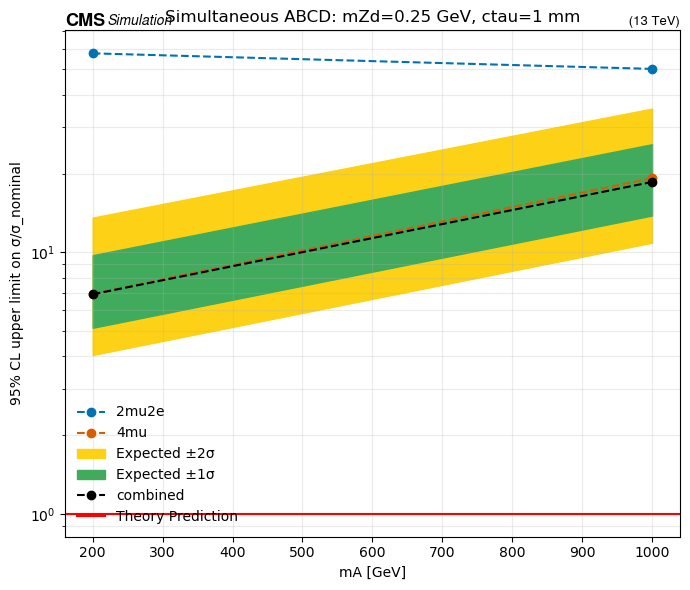

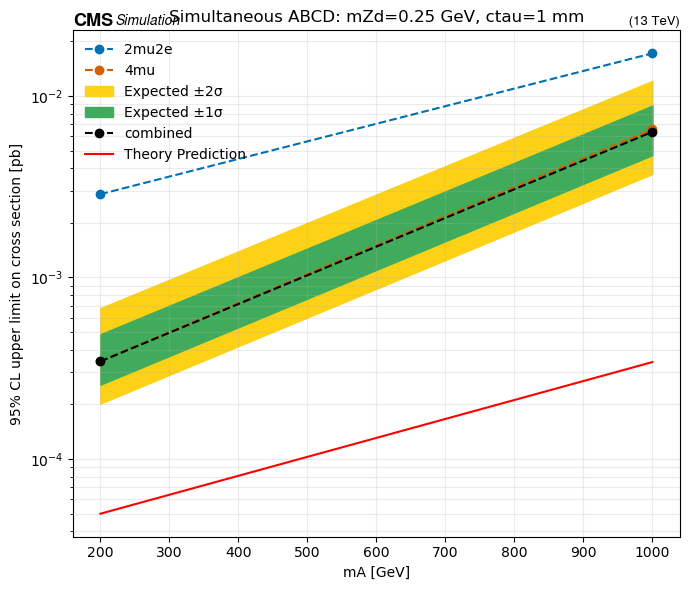

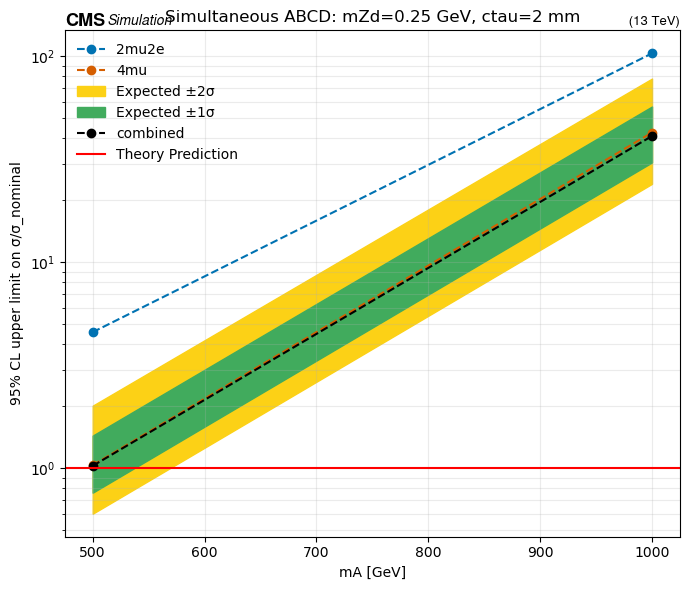

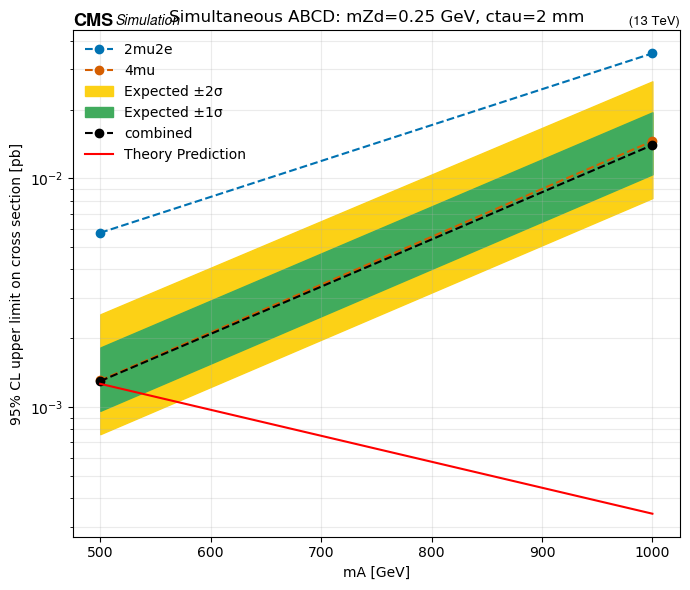

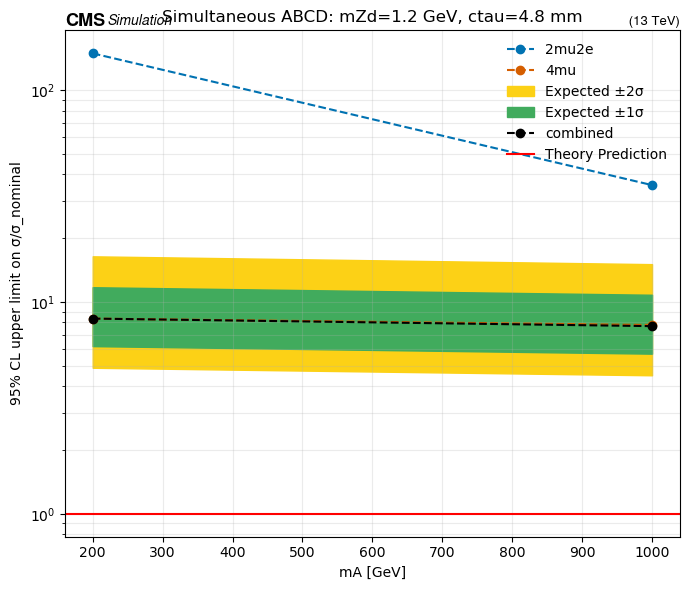

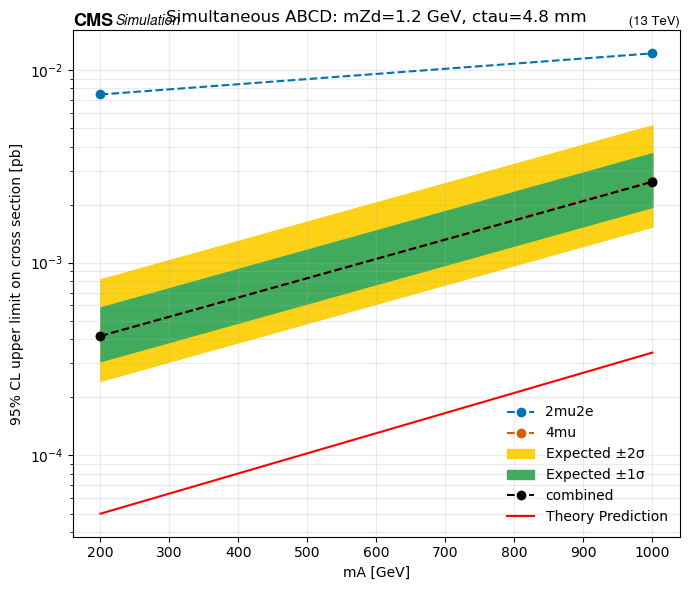

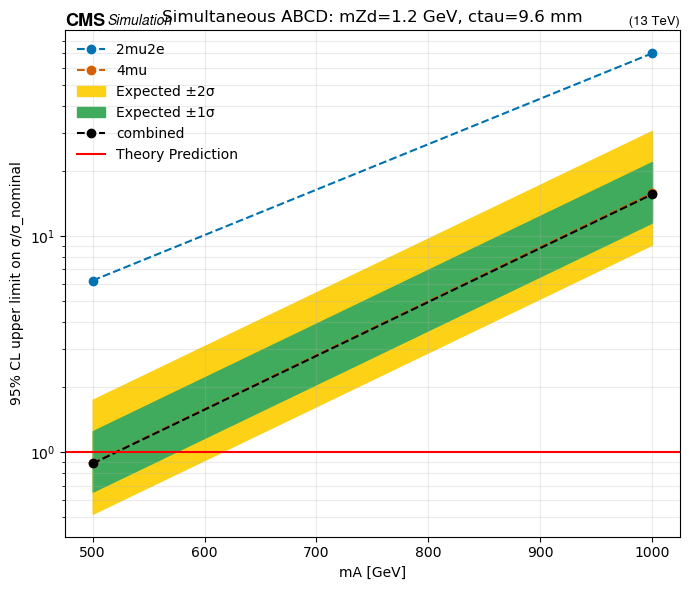

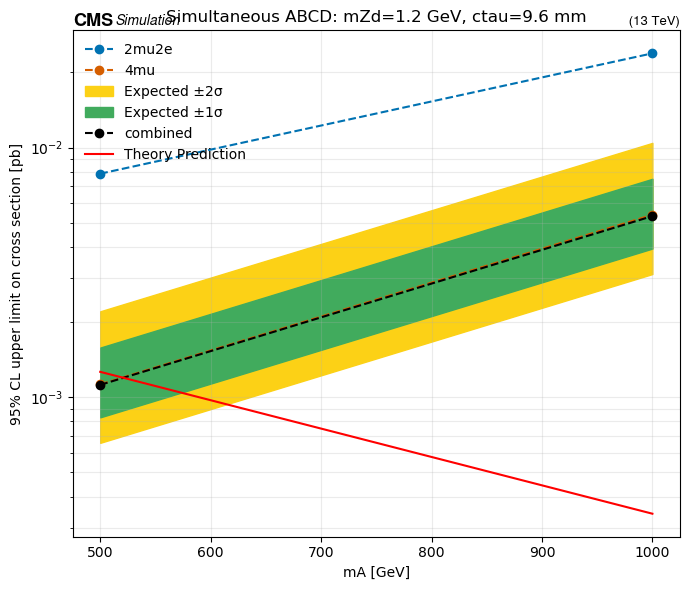

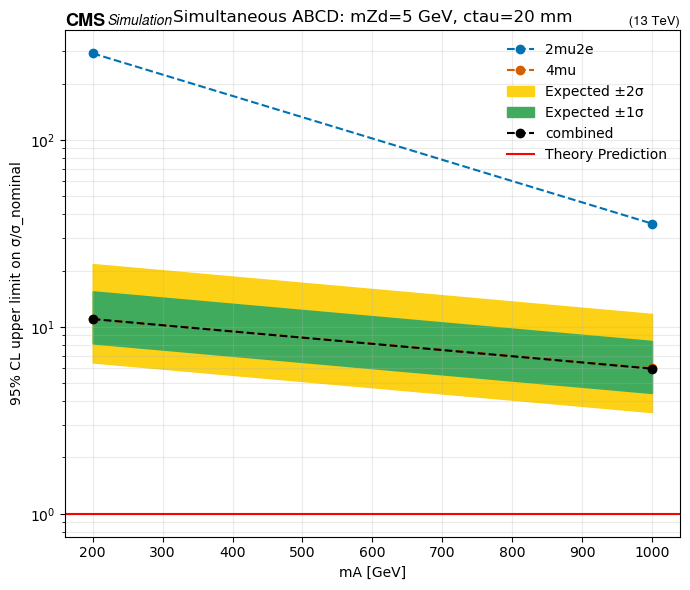

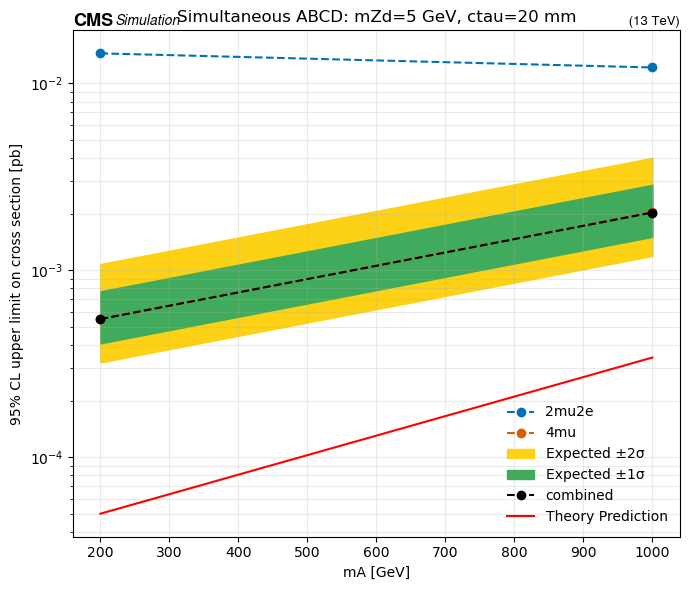

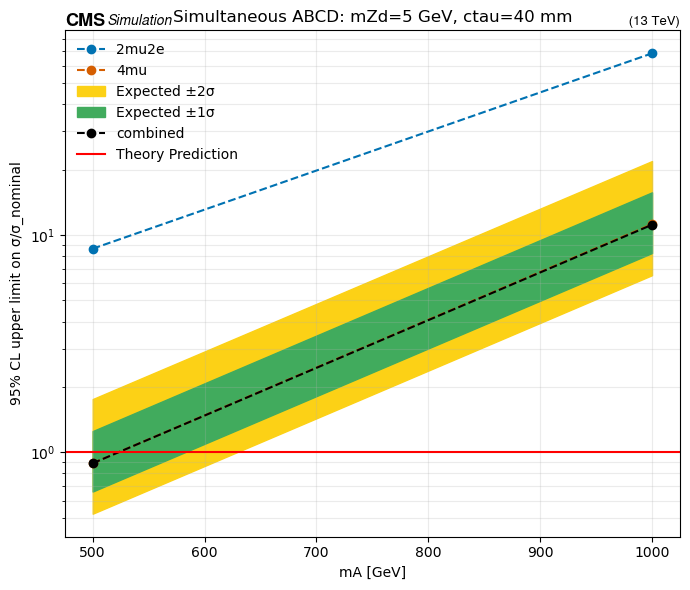

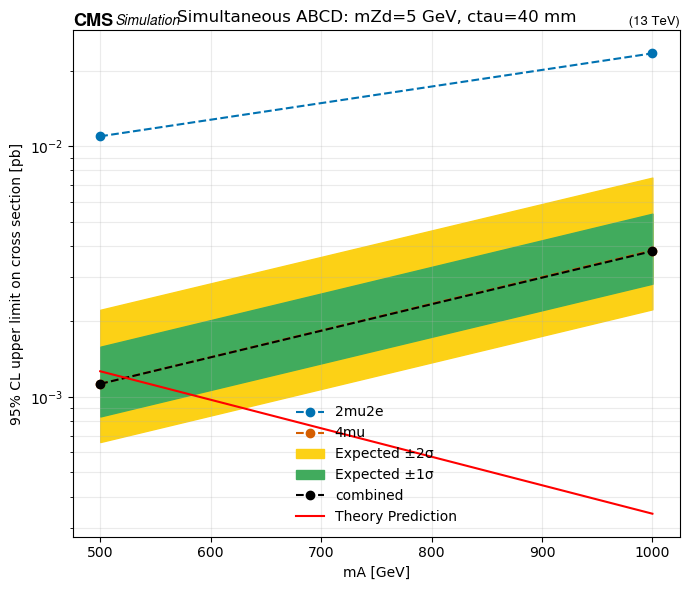

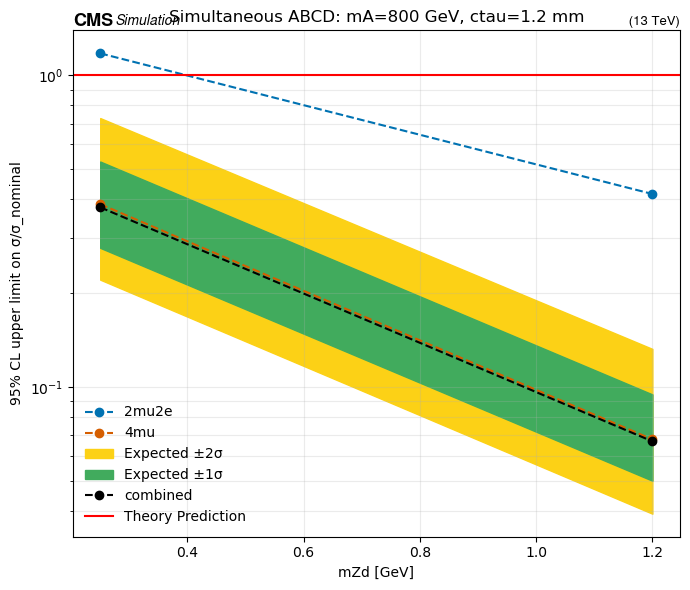

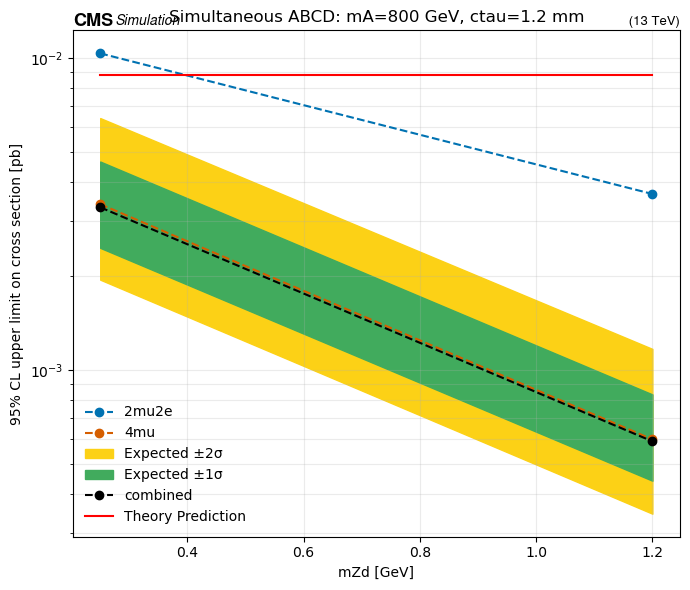

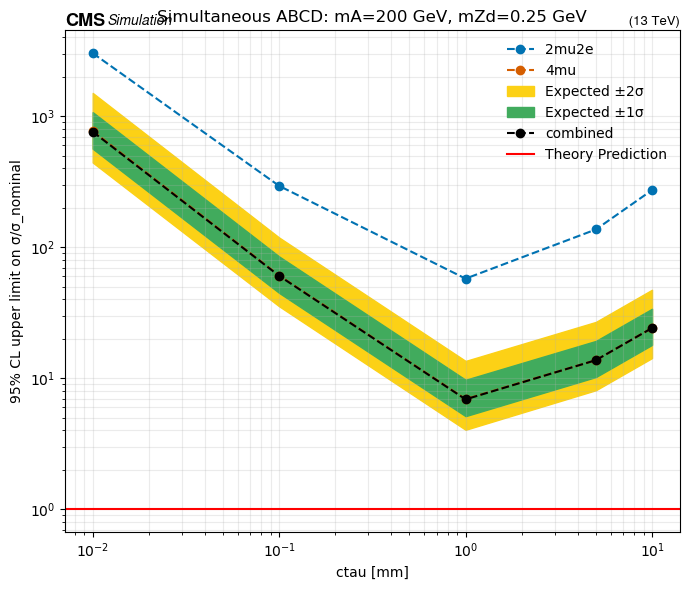

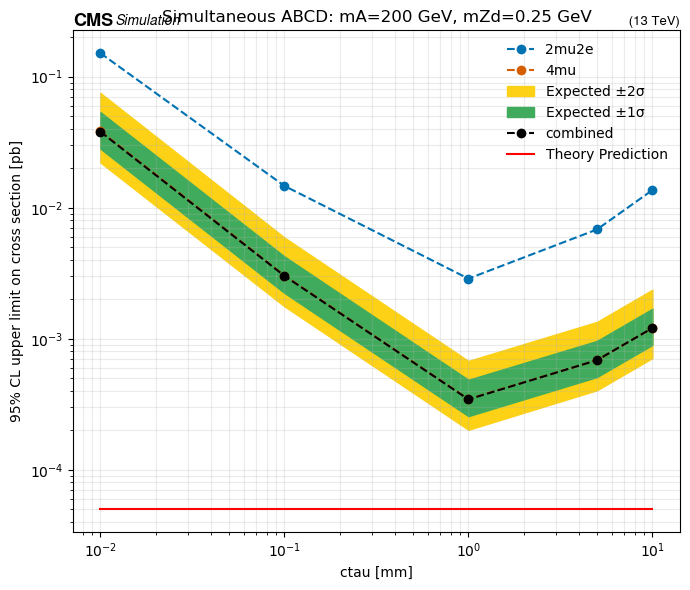

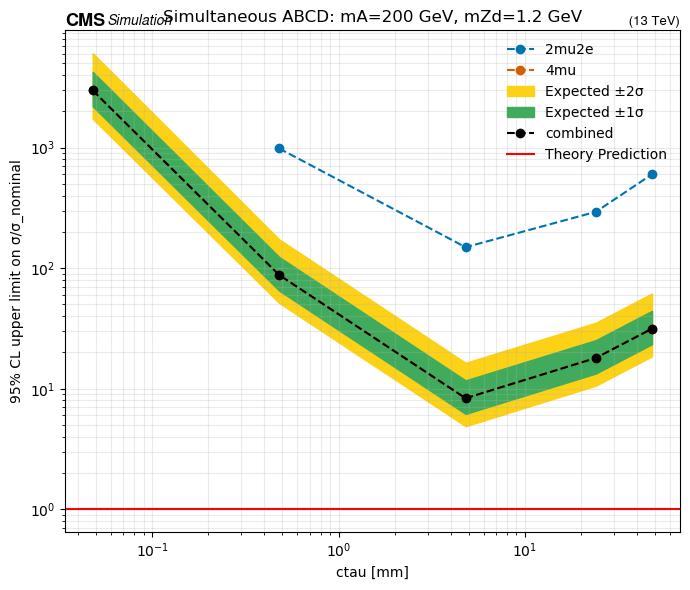

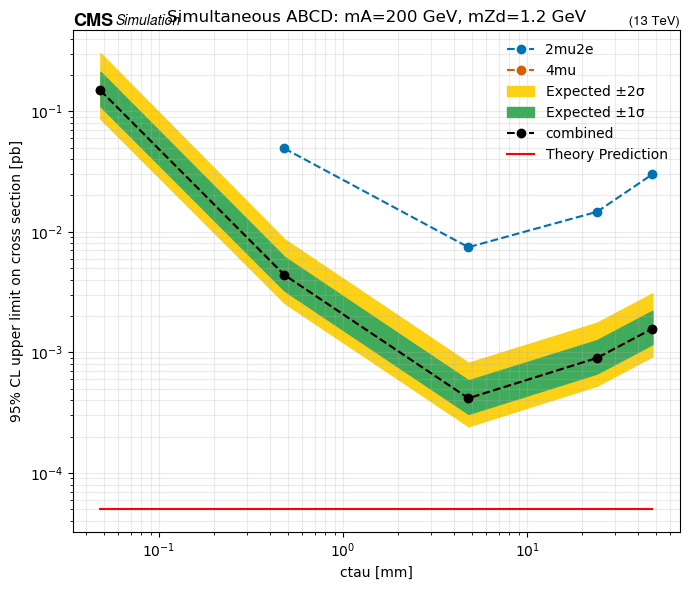

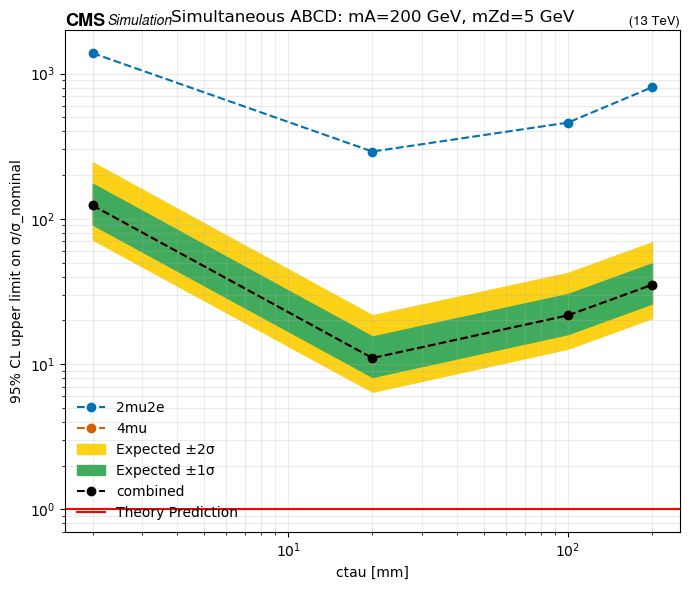

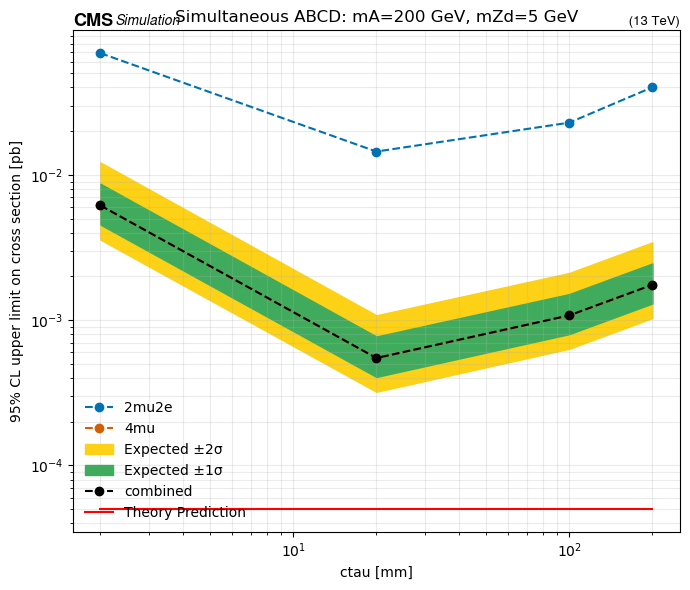

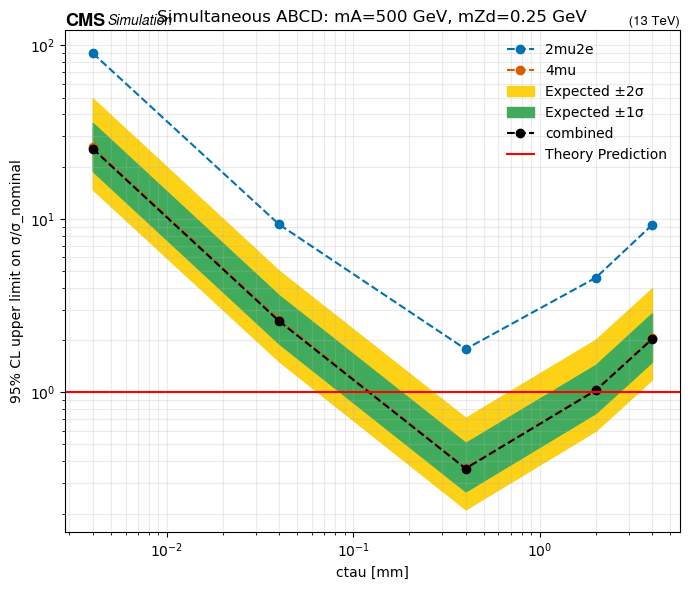

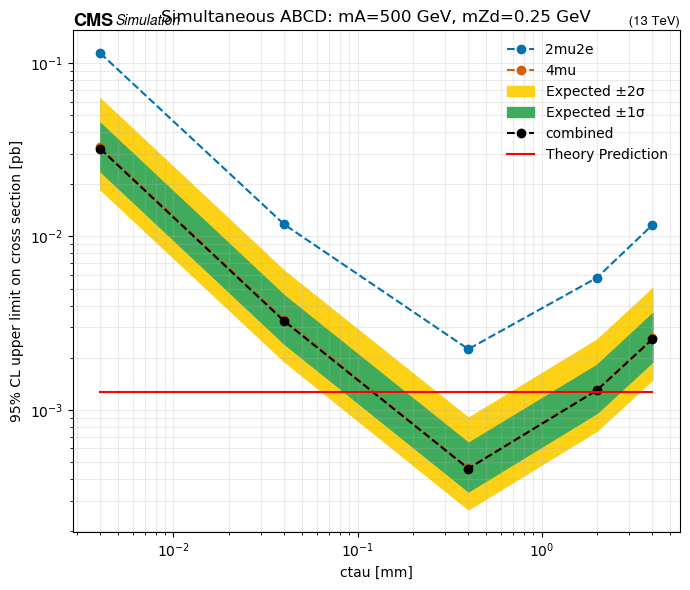

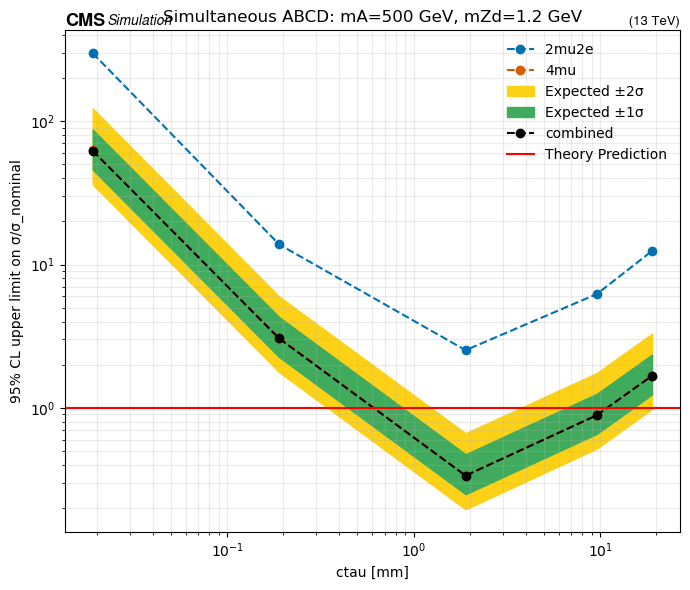

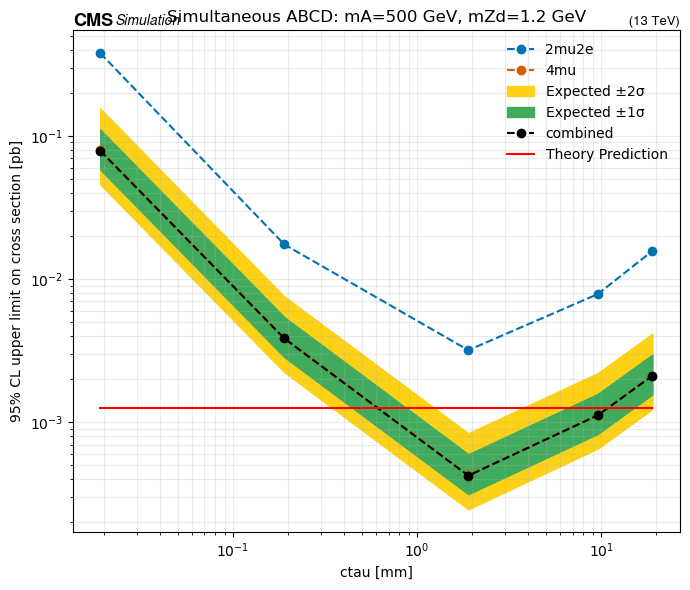

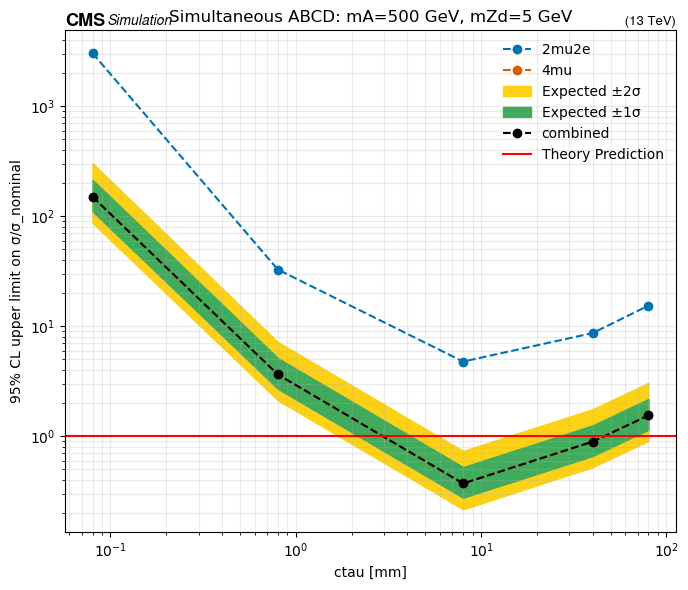

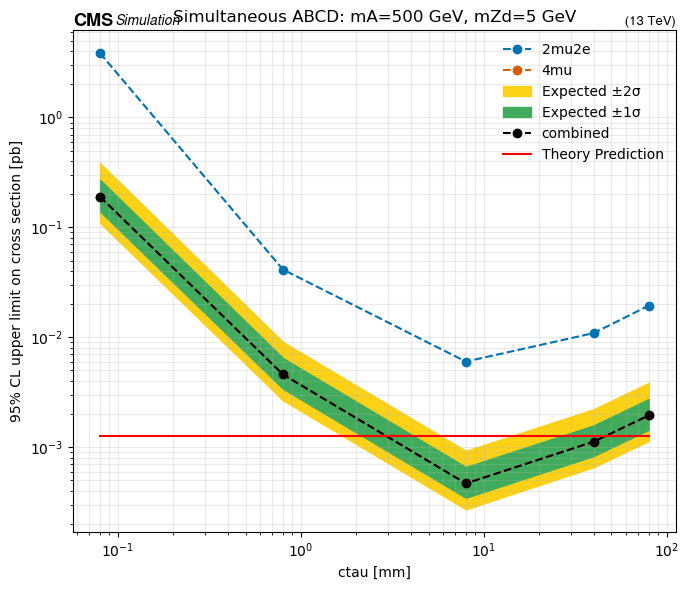

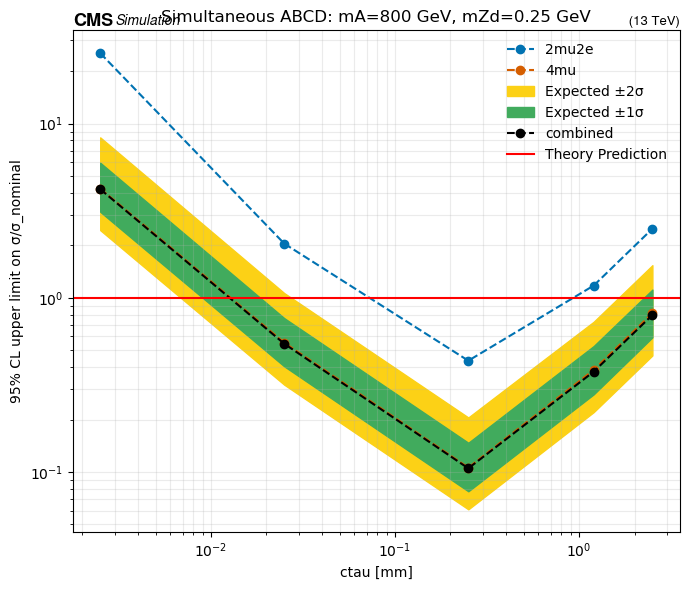

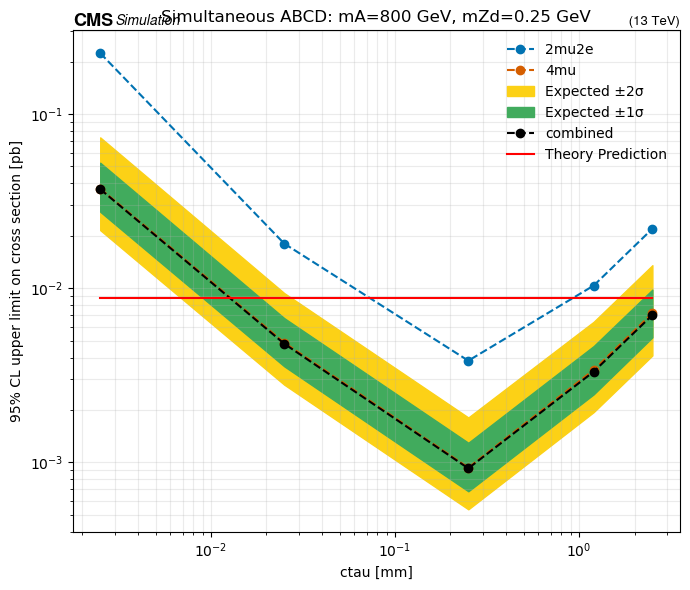

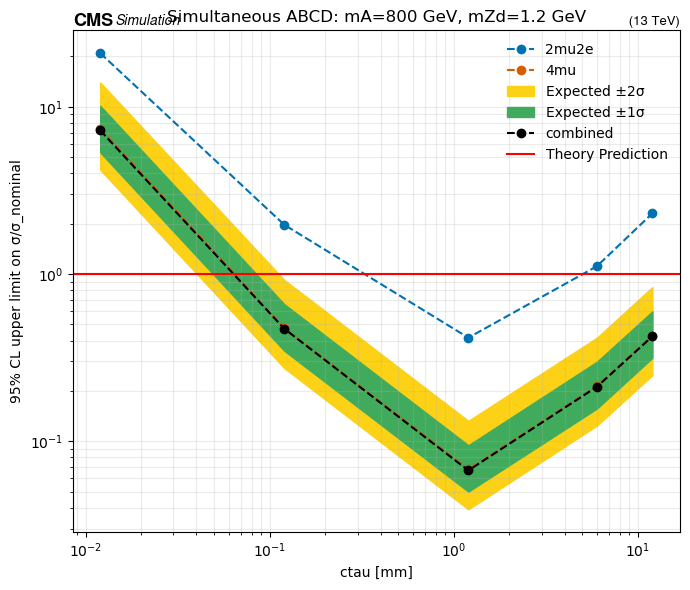

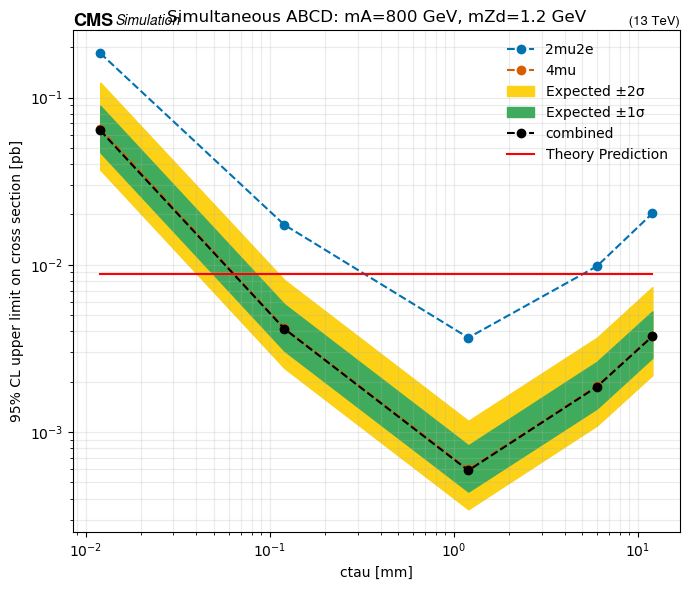

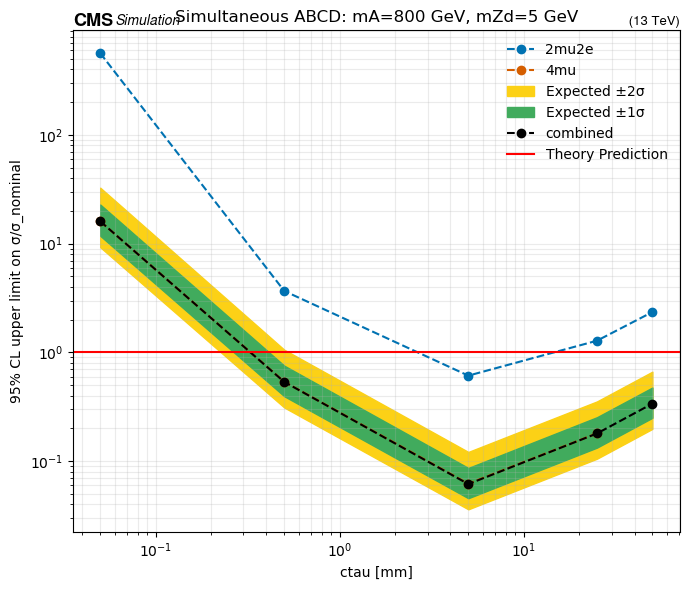

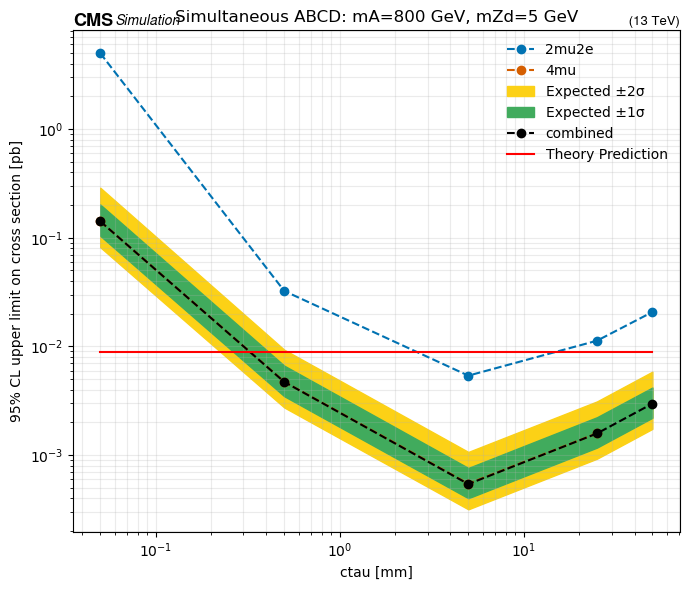

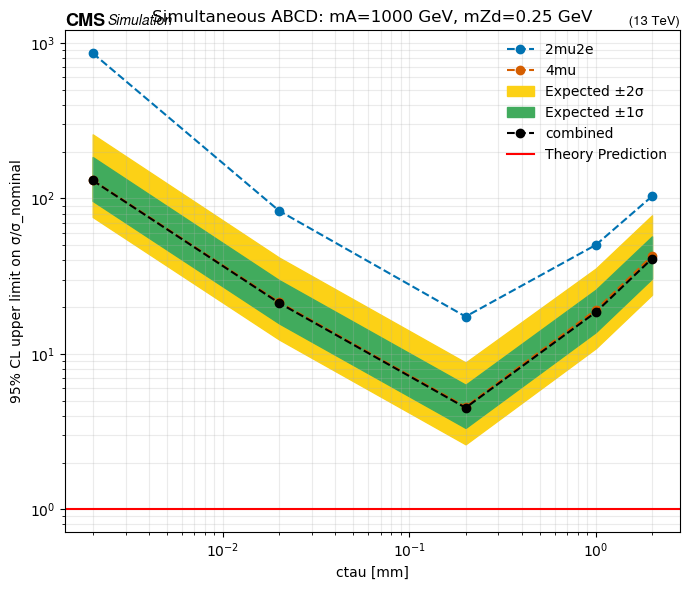

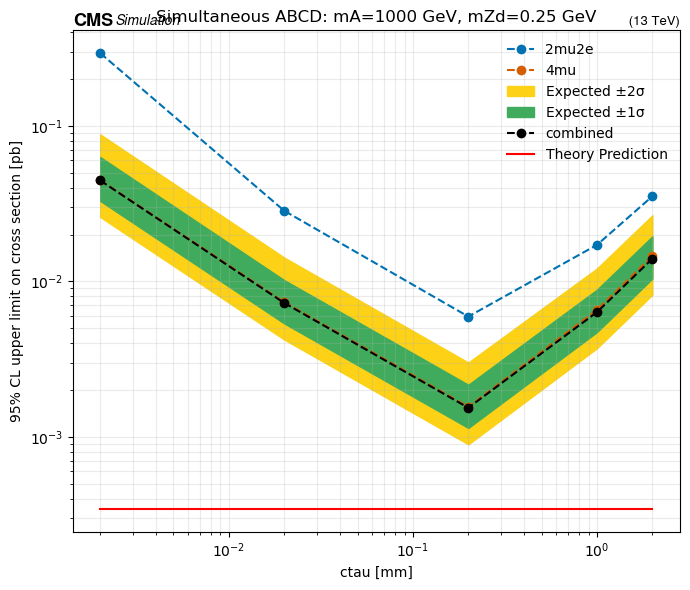

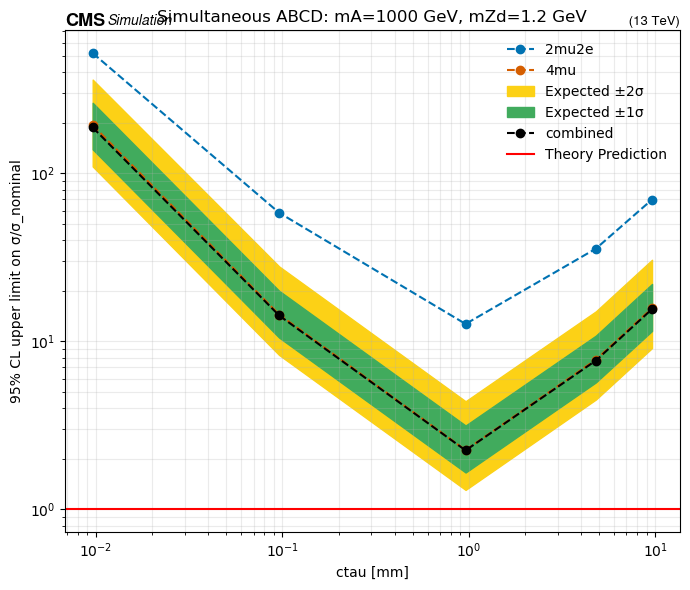

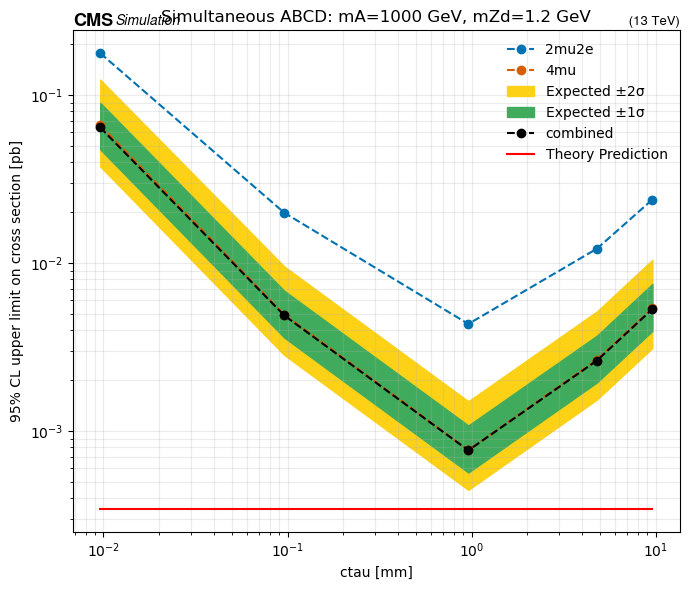

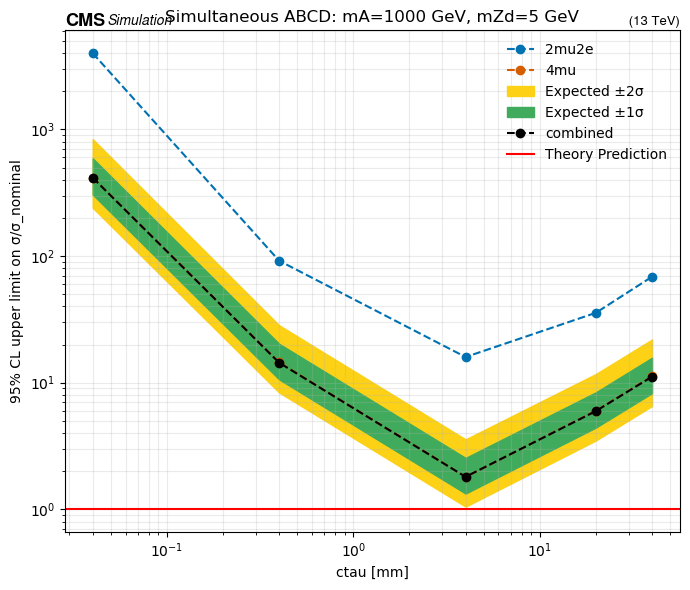

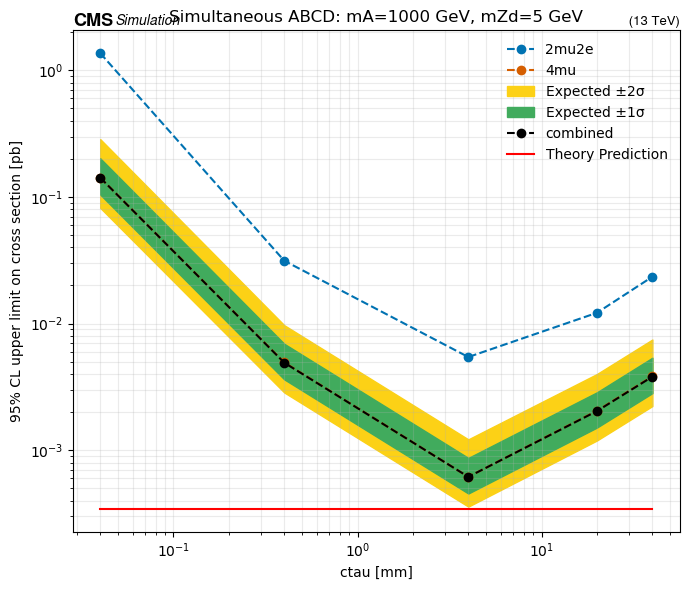

ratio plots: 19 absolute cross-section plots: 19
saved to: /home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/studies/ABCD_Study/combine_cv_simultaneous_abcd/plots


In [7]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import mplhep as hep
import pandas as pd
import yaml

PLOT_BASE = Path.cwd().resolve()
if PLOT_BASE.name != 'ABCD_Study':
    candidates = [PLOT_BASE/'studies'/'ABCD_Study', PLOT_BASE/'sidm'/'studies'/'ABCD_Study']
    PLOT_BASE = next((path for path in candidates if path.is_dir()), candidates[-1])
OUT = PLOT_BASE/'combine_cv_simultaneous_abcd'
SIGNAL_DIR = PLOT_BASE/'ABCD_landing_10ch_cosmic_veto_v1_signal_full_merged_samples_v1'
KEYS = ['mA_GeV','mZd_GeV','ctau_mm']

PLOTS = OUT/'plots'
PLOTS.mkdir(parents=True, exist_ok=True)

# Parse된 기존 결과를 직접 읽으므로 plotting만 다시 할 때 Combine 재실행이 필요 없다.
limits_to_plot = pd.read_csv(OUT/'expected_limits.csv')

# 각 physical point의 nominal cross section은 signal landing metadata에서 읽는다.
xsec_rows = []
plot_pattern = re.compile(r'^(?P<topology>2Mu2E|4Mu)_(?P<mA>[0-9p]+)GeV_(?P<mZd>[0-9p]+)GeV_(?P<ctau>[0-9p]+)mm$')
for meta_path in sorted(SIGNAL_DIR.glob('*.meta.yaml')):
    sample = meta_path.name.removesuffix('.meta.yaml')
    match = plot_pattern.match(sample)
    if match is None:
        continue
    fields = match.groupdict()
    point = {'topology': '2mu2e' if fields['topology'] == '2Mu2E' else '4mu',
             'mA_GeV': float(fields['mA'].replace('p','.')),
             'mZd_GeV': float(fields['mZd'].replace('p','.')),
             'ctau_mm': float(fields['ctau'].replace('p','.'))}
    if point['mA_GeV'] < 200:
        continue
    with open(meta_path) as stream:
        meta = yaml.safe_load(stream)
    matches = [entry for entry in meta['samples'] if entry['name'] == sample]
    if len(matches) != 1 or matches[0].get('xsec_pb') is None:
        raise ValueError(f'Invalid nominal cross section metadata: {meta_path}')
    xsec_rows.append({**{key: point[key] for key in KEYS},
                      'topology': point['topology'],
                      'xsec_nominal_pb': float(matches[0]['xsec_pb'])})

xsec_table = pd.DataFrame(xsec_rows)
xsec_counts = xsec_table.groupby(KEYS).xsec_nominal_pb.nunique()
if not (xsec_counts == 1).all():
    raise ValueError('Topology-dependent nominal cross section at one or more physical points')
xsec_by_point = xsec_table.groupby(KEYS, as_index=False).xsec_nominal_pb.first()
limits_to_plot = limits_to_plot.merge(xsec_by_point, on=KEYS, how='left', validate='many_to_one')
if limits_to_plot.xsec_nominal_pb.isna().any() or not (limits_to_plot.xsec_nominal_pb > 0).all():
    raise ValueError('Missing or non-positive nominal signal cross section')

quantile_columns = ['exp_m2','exp_m1','exp_median','exp_p1','exp_p2']
for column in quantile_columns:
    limits_to_plot[f'{column}_xsec_pb'] = limits_to_plot[column] * limits_to_plot.xsec_nominal_pb


def plot_scan(frame, x, xlabel, title, path, logx=False):
    fig, ax = plt.subplots(figsize=(7,6))
    colors = {'2mu2e':'#0072B2', '4mu':'#D55E00', 'combined':'black'}
    for channel, color in colors.items():
        selected = frame[frame.channel == channel].sort_values(x)
        if len(selected) < 2:
            continue
        xv = selected[x].to_numpy(float)
        if channel == 'combined':
            ax.fill_between(xv, selected.exp_m2, selected.exp_p2,
                            color='#FCD116', label='Expected ±2σ')
            ax.fill_between(xv, selected.exp_m1, selected.exp_p1,
                            color='#41AB5D', label='Expected ±1σ')
        ax.plot(xv, selected.exp_median, 'o--', color=color, label=channel)
    if not ax.lines:
        plt.close(fig)
        return 0
    ax.axhline(1, color='red', label='Theory Prediction')
    ax.set_yscale('log')
    if logx:
        ax.set_xscale('log')
    ax.set(xlabel=xlabel, ylabel='95% CL upper limit on σ/σ_nominal', title=title)
    ax.grid(True, which='both', alpha=.25)
    ax.legend(frameon=False)
    hep.cms.label(data=False, com=13, ax=ax)
    fig.tight_layout()
    fig.savefig(path, dpi=180)
    plt.show()
    plt.close(fig)
    return 1


def plot_xsec_scan(frame, x, xlabel, title, path, logx=False):
    fig, ax = plt.subplots(figsize=(7,6))
    colors = {'2mu2e':'#0072B2', '4mu':'#D55E00', 'combined':'black'}
    for channel, color in colors.items():
        selected = frame[frame.channel == channel].sort_values(x)
        if len(selected) < 2:
            continue
        xv = selected[x].to_numpy(float)
        if channel == 'combined':
            ax.fill_between(xv, selected.exp_m2_xsec_pb, selected.exp_p2_xsec_pb,
                            color='#FCD116', label='Expected ±2σ')
            ax.fill_between(xv, selected.exp_m1_xsec_pb, selected.exp_p1_xsec_pb,
                            color='#41AB5D', label='Expected ±1σ')
        ax.plot(xv, selected.exp_median_xsec_pb, 'o--', color=color, label=channel)
    if not ax.lines:
        plt.close(fig)
        return 0
    nominal = frame.groupby(x, as_index=False).xsec_nominal_pb.first().sort_values(x)
    ax.plot(nominal[x], nominal.xsec_nominal_pb, color='red', label='Theory Prediction')
    ax.set_yscale('log')
    if logx:
        ax.set_xscale('log')
    ax.set(xlabel=xlabel, ylabel='95% CL upper limit on cross section [pb]', title=title)
    ax.grid(True, which='both', alpha=.25)
    ax.legend(frameon=False)
    hep.cms.label(data=False, com=13, ax=ax)
    fig.tight_layout()
    fig.savefig(path, dpi=180)
    plt.show()
    plt.close(fig)
    return 1


nplots = 0
nxsec_plots = 0
for (mzd,ctau), frame in limits_to_plot.groupby(['mZd_GeV','ctau_mm']):
    title = f'Simultaneous ABCD: mZd={mzd:g} GeV, ctau={ctau:g} mm'
    nplots += plot_scan(frame, 'mA_GeV', 'mA [GeV]', title,
                        PLOTS/f'mA_mZd{mzd:g}_ctau{ctau:g}mm.png')
    nxsec_plots += plot_xsec_scan(frame, 'mA_GeV', 'mA [GeV]', title,
                                  PLOTS/f'mA_mZd{mzd:g}_ctau{ctau:g}mm_xsec_pb.png')
for (ma,ctau), frame in limits_to_plot.groupby(['mA_GeV','ctau_mm']):
    title = f'Simultaneous ABCD: mA={ma:g} GeV, ctau={ctau:g} mm'
    nplots += plot_scan(frame, 'mZd_GeV', 'mZd [GeV]', title,
                        PLOTS/f'mZd_mA{ma:g}_ctau{ctau:g}mm.png')
    nxsec_plots += plot_xsec_scan(frame, 'mZd_GeV', 'mZd [GeV]', title,
                                  PLOTS/f'mZd_mA{ma:g}_ctau{ctau:g}mm_xsec_pb.png')
for (ma,mzd), frame in limits_to_plot.groupby(['mA_GeV','mZd_GeV']):
    title = f'Simultaneous ABCD: mA={ma:g} GeV, mZd={mzd:g} GeV'
    nplots += plot_scan(frame, 'ctau_mm', 'ctau [mm]', title,
                        PLOTS/f'ctau_mA{ma:g}_mZd{mzd:g}.png', True)
    nxsec_plots += plot_xsec_scan(frame, 'ctau_mm', 'ctau [mm]', title,
                                  PLOTS/f'ctau_mA{ma:g}_mZd{mzd:g}_xsec_pb.png', True)

print('ratio plots:', nplots, 'absolute cross-section plots:', nxsec_plots)
print('saved to:', PLOTS)
